In [4]:
import numpy as np
import pandas as pd
import os
import zipfile
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.express as px
import random
from PIL import Image
import plotly.graph_objects as go
for dirname, _,filenames in os.walk('/D:/pro_info/task3/'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

In [5]:
import os
print("current folder:", os.getcwd())
print("files in this folder:", os.listdir())

current folder: d:\pro_info\task3
files in this folder: ['data', 'myenv', 'test1', 'train', 'Untitled-1.ipynb']


In [6]:
with zipfile.ZipFile('D:/pro_info/task3/data/train.zip','r') as zip_ref:
    zip_ref.extractall('train')
with zipfile.ZipFile('D:/pro_info/task3/data/test1.zip','r') as zip_ref:
        zip_ref.extractall('test1')

In [7]:
train_dir='train/train'
test_dir='test1/test1'

In [8]:
def load_images(folder,img_size=(64,64),sample_count=20,label_filter=None):
    images=[]
    labels=[]
    filenames=os.listdir(folder)
    if label_filter is not None:
        filenames=[fname for fname in filenames if label_filter.lower() in fname.lower()]
    random.shuffle(filenames)
    count = 0

    for img in filenames:
        if count >= sample_count:
            break

        try:
            path = os.path.join(folder, img)

            # Open image safely
            img_pil = Image.open(path).convert('RGB')   # FIXED
            img_pil = img_pil.resize(img_size)

            images.append(np.array(img_pil))
            labels.append(0 if 'cat' in img.lower() else 1)

            count += 1   # only count valid images

        except Exception as e:
            print(f"Skipping {img}")   # cleaner output

    return np.array(images), np.array(labels)

In [9]:
def visualize_images(images, labels, sample_count=20):
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()
    
    for i in range(sample_count):
        axes[i].imshow(images[i])
        axes[i].set_title('Cat' if labels[i] == 0 else 'Dog')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [10]:
train_dir='train/train'
cat_images, cat_labels = load_images(train_dir, sample_count=20, label_filter='cat')

(20, 64, 64, 3)
(20,)


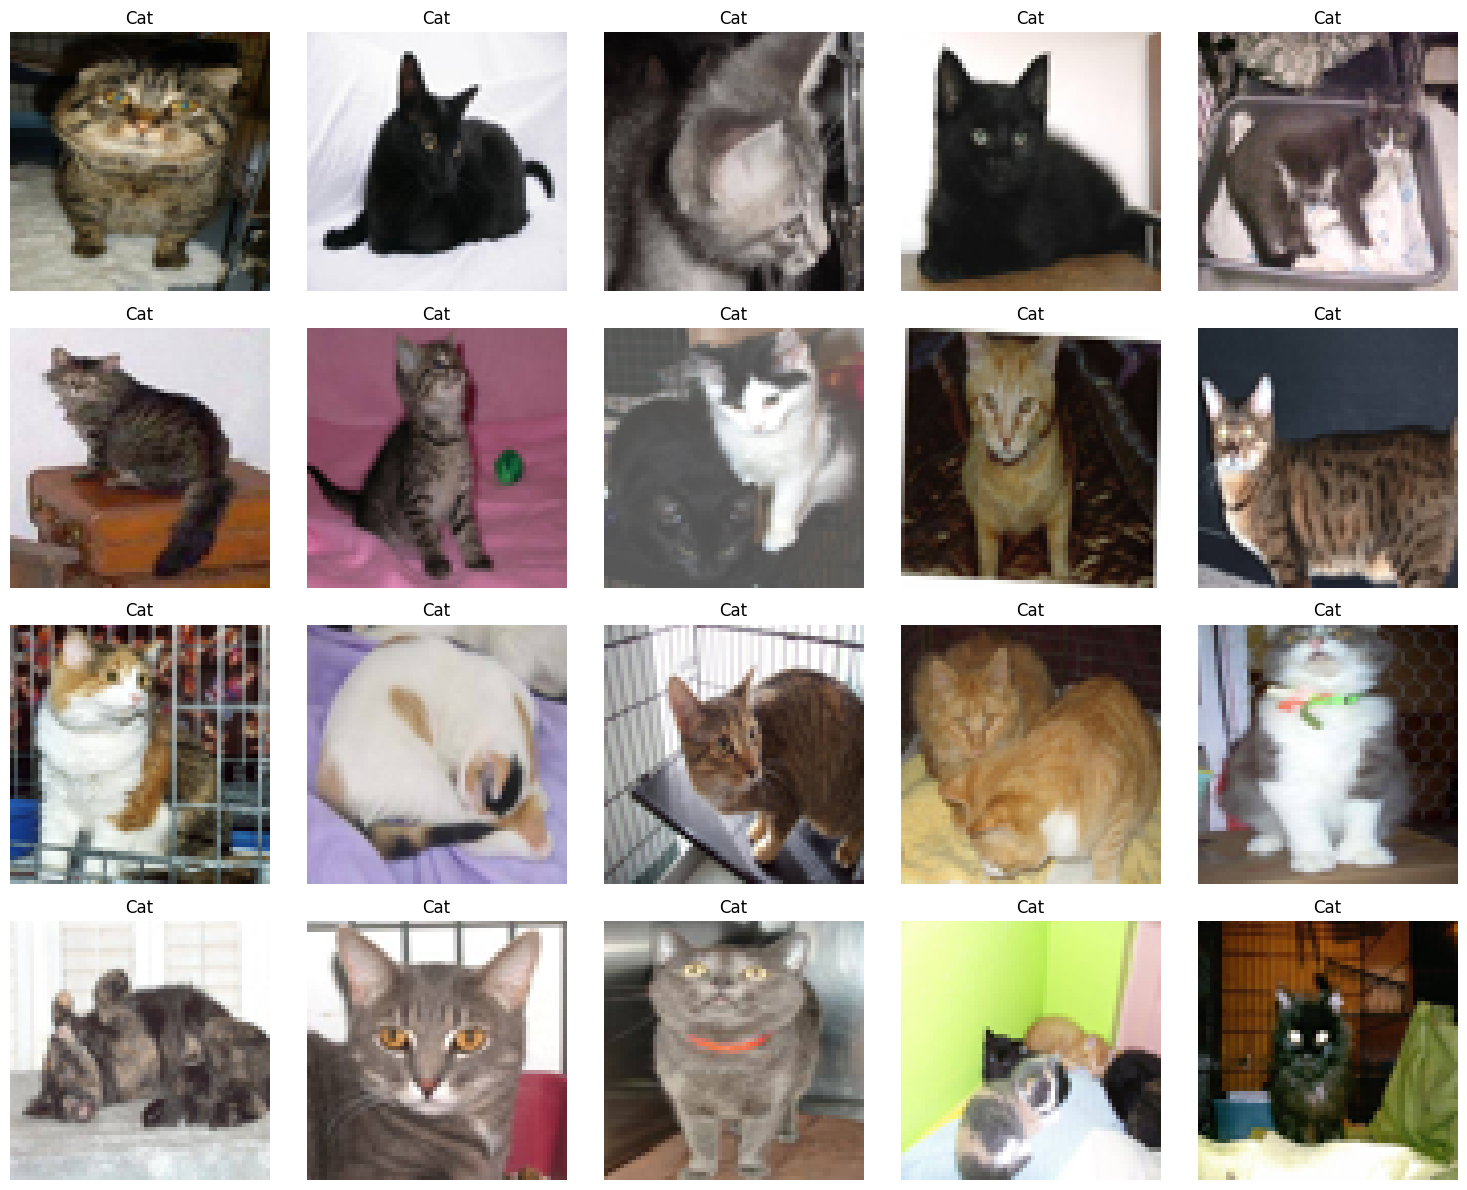

In [11]:
print(cat_images.shape)
print(cat_labels.shape)
visualize_images(cat_images, cat_labels)

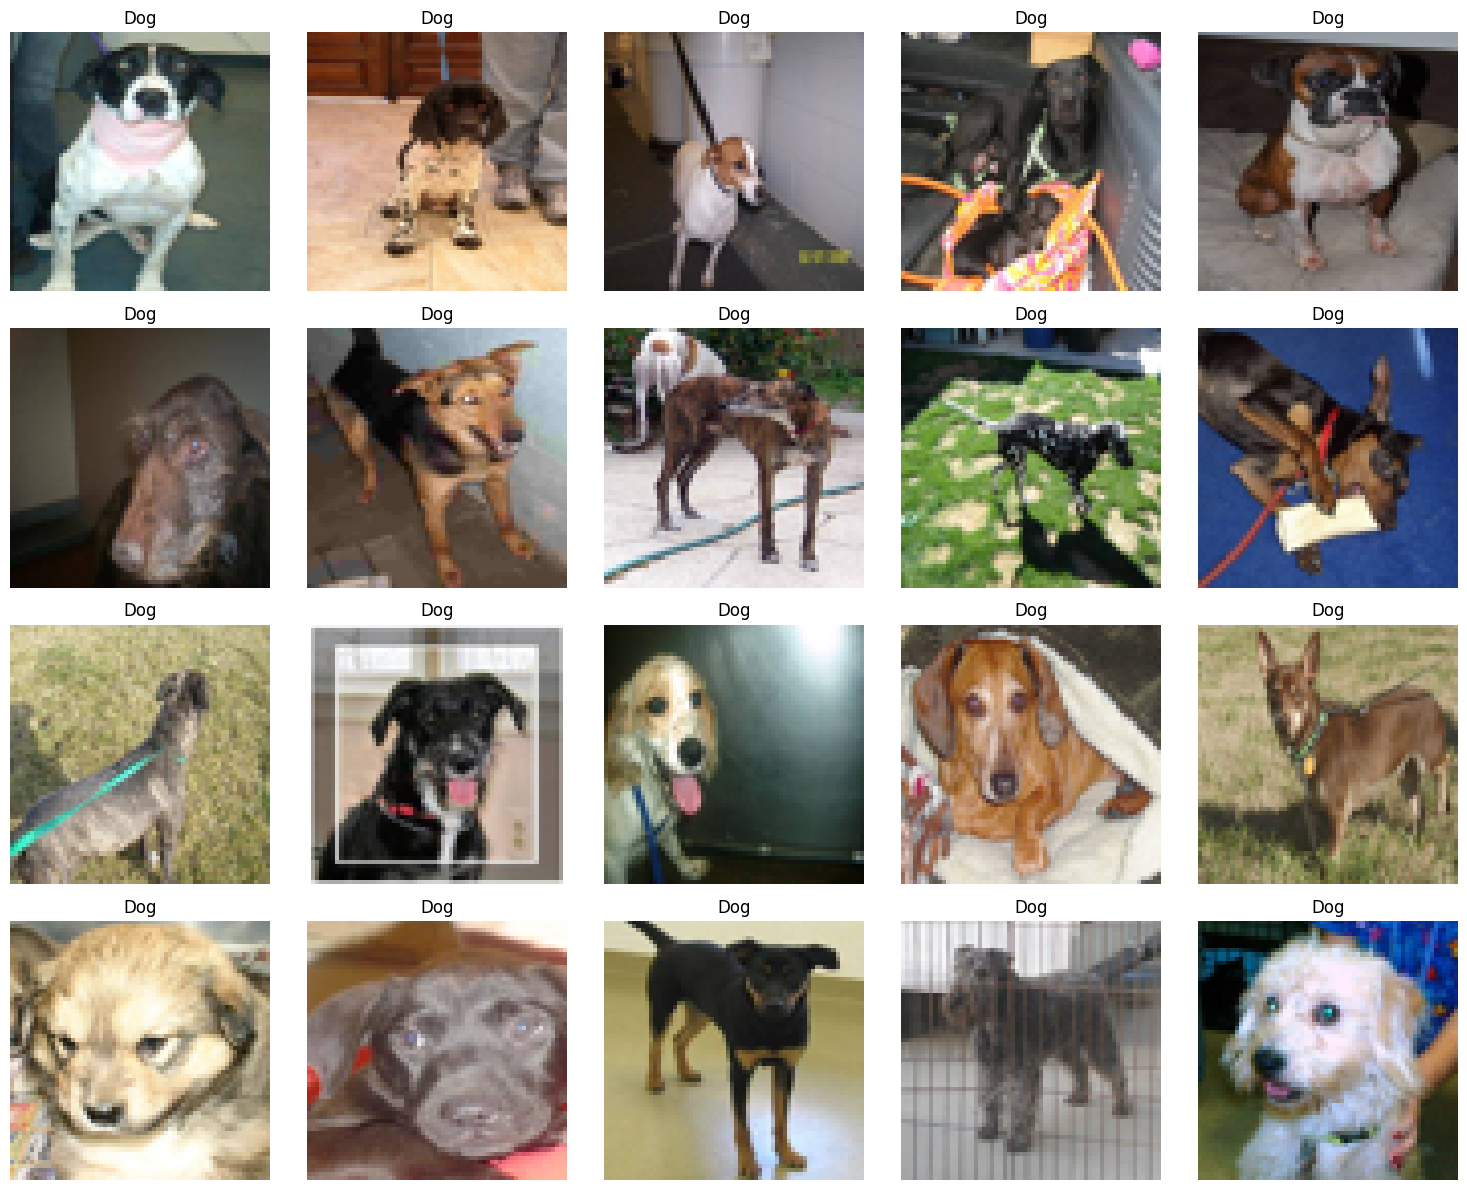

In [12]:
dog_images, dog_labels = load_images(train_dir, sample_count=20, label_filter='dog')
visualize_images(dog_images, dog_labels, sample_count=20)

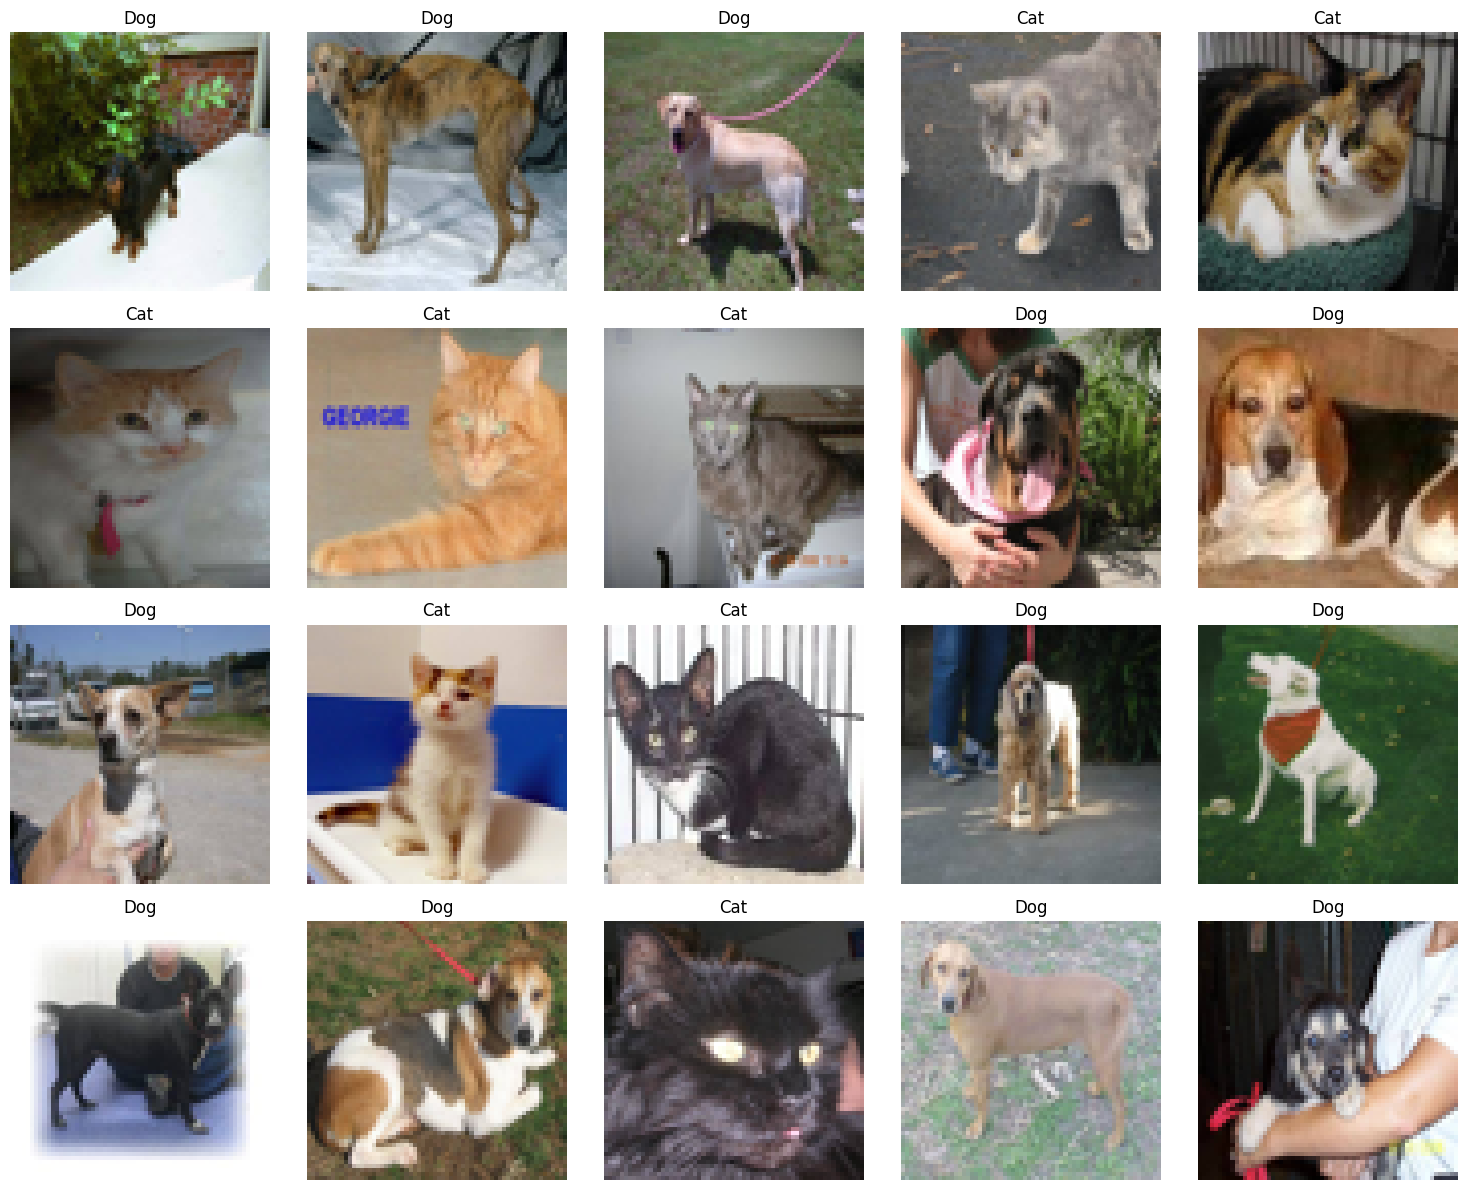

In [13]:
all_images, all_labels = load_images(train_dir, sample_count=20)
visualize_images(all_images, all_labels, sample_count=20)

In [14]:
images, labels = load_images(train_dir, sample_count=8000) 
images = images / 255.0

In [15]:
print("Shape of images array:", images.shape)

Shape of images array: (8000, 64, 64, 3)


In [16]:
print("Shape of the first image:", images[0].shape)

Shape of the first image: (64, 64, 3)


In [17]:
print(images[:2]) 
print(labels[:2])

[[[[1.         1.         1.        ]
   [0.96470588 0.96862745 0.96862745]
   [0.46666667 0.46666667 0.45490196]
   ...
   [0.53333333 0.49019608 0.84705882]
   [0.59215686 0.54901961 0.90980392]
   [0.59607843 0.55294118 0.91764706]]

  [[1.         1.         1.        ]
   [0.96470588 0.96470588 0.96078431]
   [0.49019608 0.50588235 0.48235294]
   ...
   [0.52941176 0.48627451 0.85098039]
   [0.58039216 0.5372549  0.89803922]
   [0.58823529 0.54509804 0.90588235]]

  [[1.         1.         1.        ]
   [0.98039216 0.98039216 0.98039216]
   [0.53333333 0.55686275 0.51372549]
   ...
   [0.54901961 0.50196078 0.8745098 ]
   [0.55294118 0.50980392 0.87058824]
   [0.57254902 0.5254902  0.88235294]]

  ...

  [[0.89803922 0.78039216 0.59607843]
   [0.94509804 0.84313725 0.66666667]
   [0.94509804 0.84313725 0.67058824]
   ...
   [0.45882353 0.41568627 0.74901961]
   [0.38823529 0.34509804 0.65490196]
   [0.37254902 0.3254902  0.64313725]]

  [[0.92941176 0.82352941 0.65098039]
   [0.9

In [18]:
n_samples, img_height, img_width, img_channels = images.shape
images_flat = images.reshape(n_samples, -1)

In [19]:
scaler = StandardScaler()
images_flat_scaled = scaler.fit_transform(images_flat)

In [20]:
perplexity = min(30, n_samples - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
images_tsne = tsne.fit_transform(images_flat_scaled)

In [21]:
X_train, X_val, y_train, y_val = train_test_split(images_flat_scaled, labels, test_size=0.2, random_state=42)
X_train

array([[ 0.16947377,  0.67512508,  0.56426932, ...,  1.33585758,
         1.08001334,  1.08763311],
       [ 0.82358617,  0.83309527,  0.76086049, ...,  0.80676724,
         0.85480021,  0.56357517],
       [ 1.5345779 ,  1.53678064,  1.30850732, ...,  1.68858447,
         1.63553908,  1.32054774],
       ...,
       [ 0.49652997,  0.6320423 ,  0.64852267, ..., -0.51595861,
        -1.11206117, -1.24151326],
       [-0.1433626 , -0.45938807, -0.67144661, ...,  0.20419213,
         0.16414659,  0.28698904],
       [-1.19563037, -1.14871252, -1.02250227, ...,  0.68919161,
         0.31428868,  0.21420322]], shape=(6400, 12288))

In [22]:
unique, counts = np.unique(labels, return_counts=True)
print(f"Class distribution: {dict(zip(unique, counts))}")

Class distribution: {np.int64(0): np.int64(3984), np.int64(1): np.int64(4016)}


In [23]:
def plot_tsne_data(tsne_data, labels, title):
    df_tsne = pd.DataFrame()
    df_tsne['X'] = tsne_data[:, 0]
    df_tsne['Y'] = tsne_data[:, 1]
    df_tsne['Label'] = labels
    df_tsne['Label'] = df_tsne['Label'].map({0: 'Cat', 1: 'Dog'})
    
    fig = px.scatter(df_tsne, x='X', y='Y', color='Label', title=title)
    fig.show()

plot_tsne_data(images_tsne, labels, 't-SNE visualization of Cats vs Dogs')

from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(train_dir)

test_images, test_labels = load_images(test_dir)  
test_images = test_images / 255.0


n_test_samples, test_img_height, test_img_width, test_img_channels = test_images.shape
test_images_flat = test_images.reshape(n_test_samples, -1)
test_images_flat_scaled = scaler.transform(test_images_flat)

test_images_flat_scaled = scaler.transform(test_images_flat)

test_perplexity = min(30, n_test_samples - 1)
test_tsne = TSNE(n_components=2, perplexity=test_perplexity, random_state=42)
test_images_tsne = test_tsne.fit_transform(test_images_flat_scaled)

y_test_pred = svm.predict(test_images_flat_scaled)